In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv(r"C:\Users\swathikanike\Downloads\telcomproject\Telco_Customer_Churn.csv")

In [3]:
df.shape

(7043, 21)

In [4]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [9]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
# Fix SeniorCitizen encoding
df["SeniorCitizen"] = df["SeniorCitizen"].replace({0 : 'No', 1 : 'Yes'})

In [12]:
df["SeniorCitizen"].value_counts()

SeniorCitizen
No     5901
Yes    1142
Name: count, dtype: int64

In [13]:
# Overall Churn rate
churn_rate = df["Churn"].value_counts(normalize = True) * 100
churn_rate

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [14]:
# Churn by Contract Type
df.groupby("Contract")["Churn"].value_counts(normalize=True)

Contract        Churn
Month-to-month  No       0.572903
                Yes      0.427097
One year        No       0.887305
                Yes      0.112695
Two year        No       0.971681
                Yes      0.028319
Name: proportion, dtype: float64

In [15]:
# Create tenure buckets (New vs Old)
df['tenure_group'] = pd.cut(df['tenure'],
                             bins=[0, 12, 24, 48, 72],
                             labels=['New (0-12m)',
                                     'Growing (12-24m)',
                                     'Established (24-48m)',
                                     'Loyal (48-72m)'])

df.groupby('tenure_group')['Churn'].value_counts(normalize=True)

C:\Users\swathikanike\AppData\Local\Temp\ipykernel_20900\348218179.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('tenure_group')['Churn'].value_counts(normalize=True)


tenure_group          Churn
New (0-12m)           No       0.523218
                      Yes      0.476782
Growing (12-24m)      No       0.712891
                      Yes      0.287109
Established (24-48m)  No       0.796110
                      Yes      0.203890
Loyal (48-72m)        No       0.904868
                      Yes      0.095132
Name: proportion, dtype: float64

In [16]:
# Churn Rate by Internet Service
internet_churn = pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100
internet_churn = internet_churn['Yes'].reset_index()
internet_churn.columns = ['Internet Service', 'Churn Rate']

print(internet_churn)

  Internet Service  Churn Rate
0              DSL   18.959108
1      Fiber optic   41.892765
2               No    7.404980


In [19]:
# Feature level churn
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in service_cols:
    table = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    print(f"{col}:")
    print(table['Yes'].round(1))
    print()

OnlineSecurity:
OnlineSecurity
No                     41.8
No internet service     7.4
Yes                    14.6
Name: Yes, dtype: float64

OnlineBackup:
OnlineBackup
No                     39.9
No internet service     7.4
Yes                    21.5
Name: Yes, dtype: float64

DeviceProtection:
DeviceProtection
No                     39.1
No internet service     7.4
Yes                    22.5
Name: Yes, dtype: float64

TechSupport:
TechSupport
No                     41.6
No internet service     7.4
Yes                    15.2
Name: Yes, dtype: float64

StreamingTV:
StreamingTV
No                     33.5
No internet service     7.4
Yes                    30.1
Name: Yes, dtype: float64

StreamingMovies:
StreamingMovies
No                     33.7
No internet service     7.4
Yes                    29.9
Name: Yes, dtype: float64



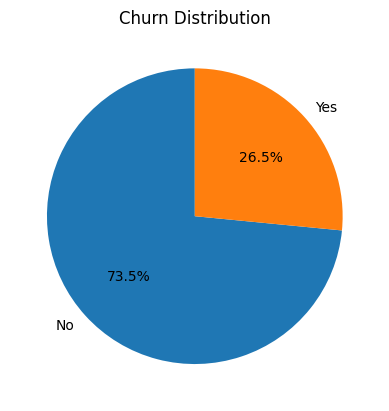

In [20]:
# Overall Churn Distribution
churn_counts = df["Churn"].value_counts()
plt.pie(churn_counts,
        labels= churn_counts.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title('Churn Distribution')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

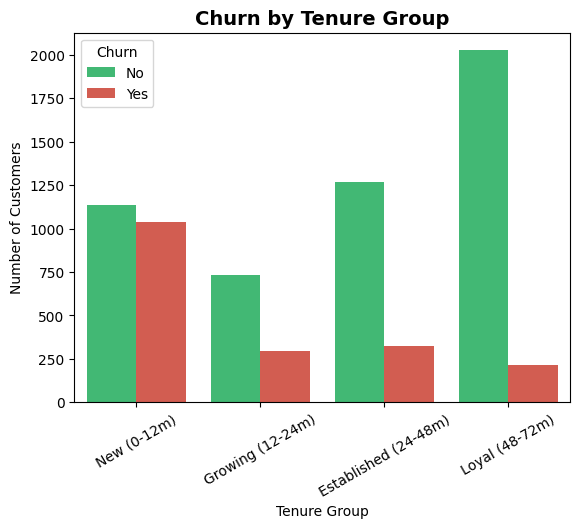

In [21]:
# Churn by Tenure Group

sns.countplot(x = "tenure_group", hue = "Churn", data = df,
              palette=["#2ecc71", "#e74c3c"])

plt.title("Churn by Tenure Group", fontsize = 14, fontweight = "bold")
plt.xlabel("Tenure Group")
plt.ylabel("Number of Customers")
plt.xticks(rotation = 30)
plt.legend(title = "Churn")
plt.show

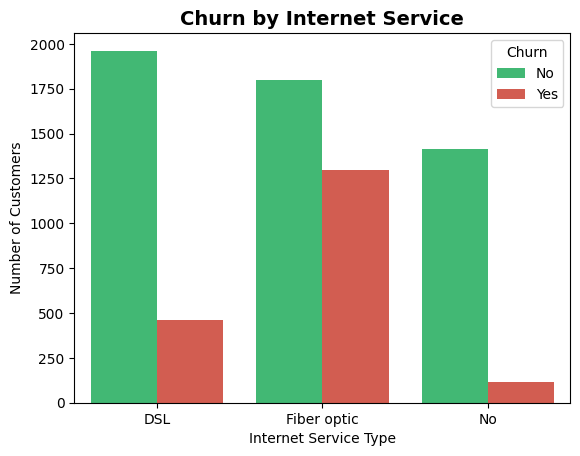

In [22]:
# Churn by Internet Service
sns.countplot(x='InternetService', hue='Churn', data=df,
              palette=['#2ecc71', '#e74c3c'])

plt.title('Churn by Internet Service', fontsize=14, fontweight='bold')
plt.xlabel('Internet Service Type')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')
plt.show()

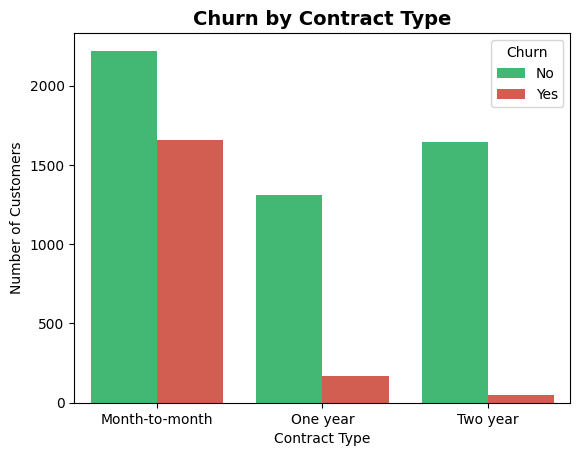

In [23]:
# Churn by Contract Type
sns.countplot(x='Contract', hue='Churn', data=df,
              palette=['#2ecc71', '#e74c3c'])

plt.title('Churn by Contract Type', fontsize=14, fontweight='bold')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')
plt.show()

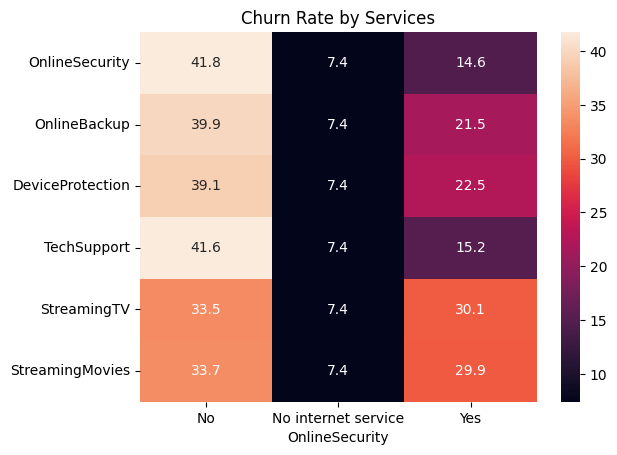

In [24]:
# heatmap

service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']

heatmap_df = pd.DataFrame()

for col in service_cols:
    temp = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    heatmap_df[col] = temp['Yes']

heatmap_df = heatmap_df.T

sns.heatmap(heatmap_df, annot=True, fmt='.1f')
plt.title('Churn Rate by Services')
plt.show()

# Insights
1. Overall 26.5 % have churned. 1 in every 4 customers is leaving
2. New customers (0-12 months) churn the most - onboarding is broken.
3. Fiber Optic customers churn the most despite paying a premium
4. Month-Month contract customers churn at 42% - 14x higher than two-year contract holders.
5. Found customers not using TechSupport or OnlineSecurity at 3x the rate of feature users - recommended proactive upsell strategy.